This notebook investigates the relationship between financial news sentiment and stock price movements by combining NLP-based sentiment scoring with historical stock return analysis.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from scipy.stats import pearsonr

In [20]:
news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
stock_df = pd.read_csv("../AAPL.csv")

In [21]:
# format='mixed' handles inconsistent datetime formats; utc=True normalizes timezones
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

news_df['trading_date'] = news_df['date'].dt.date
stock_df['trading_date'] = stock_df['Date'].dt.date

In [22]:
trading_days = set(stock_df['trading_date'])

def align_to_trading_day(date):
    while date not in trading_days:
        date = pd.to_datetime(date) + pd.Timedelta(days=1)
        date = date.date()
    return date

news_df['trading_date'] = news_df['trading_date'].apply(align_to_trading_day)

News articles published on weekends or market holidays were aligned to the next available trading day to ensure consistency with stock market activity.

TextBlob was selected because it provides lightweight polarity scoring suitable for short financial headlines and enables rapid sentiment extraction for exploratory analysis.


In [23]:
news_df['sentiment'] = news_df['headline'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

news_df['sentiment'].describe()

def classify_sentiment(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

news_df['sentiment_category'] = news_df['sentiment'].apply(classify_sentiment)

In [24]:
stock_df['daily_return'] = (
    stock_df['Close'].pct_change()
) * 100

In [25]:
daily_sentiment = news_df.groupby('trading_date')['sentiment'].mean().reset_index()

merged_df = pd.merge(
    daily_sentiment,
    stock_df[['trading_date', 'daily_return']],
    on='trading_date'
)

In [26]:
correlation, p_value = pearsonr(
    merged_df['sentiment'],
    merged_df['daily_return']
)

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.04460355768910343
P-value: 0.019131484177842224


Pearson correlation measures the linear relationship between sentiment scores and stock returns.

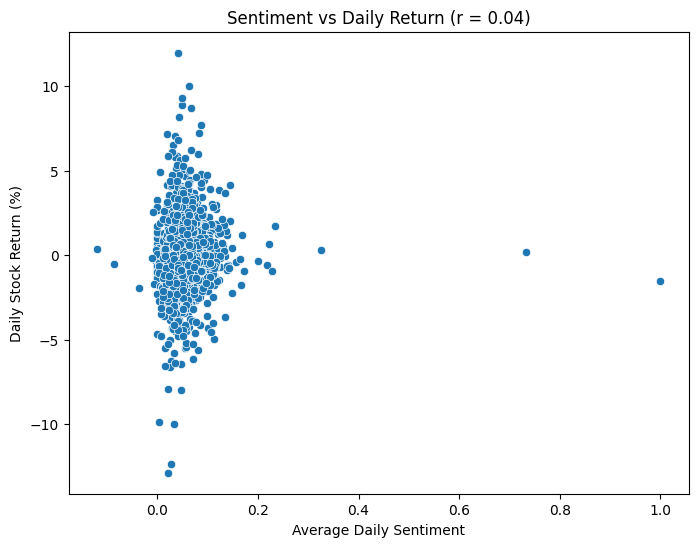

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged_df,
    x='sentiment',
    y='daily_return'
)

plt.title(f"Sentiment vs Daily Return (r = {correlation:.2f})")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Stock Return (%)")

plt.show()

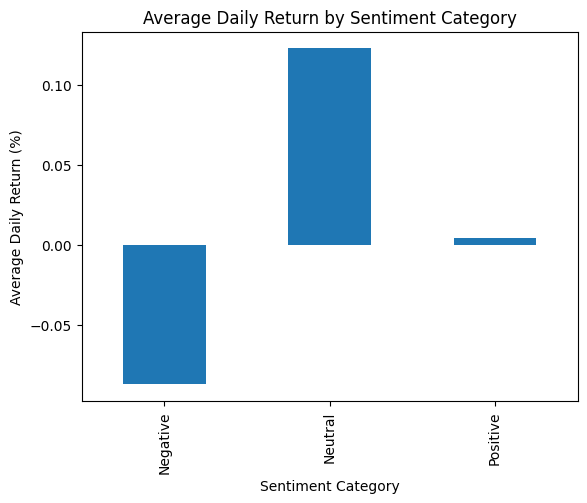

In [28]:
daily_category = news_df.groupby(
    'trading_date'
)['sentiment_category'].agg(lambda x: x.mode()[0]).reset_index()

merged_df = pd.merge(
    merged_df,
    daily_category,
    on='trading_date'
)

category_returns = merged_df.groupby(
    'sentiment_category'
)['daily_return'].mean()

category_returns.plot(kind='bar')

plt.title("Average Daily Return by Sentiment Category")
plt.xlabel("Sentiment Category")
plt.ylabel("Average Daily Return (%)")

plt.show()

The correlation coefficient indicates a weak positive relationship between news sentiment and daily stock returns. This suggests that positive financial headlines may be associated with slightly improved market performance, although the relationship is not strong enough to imply causation.

This analysis provides preliminary evidence that financial news sentiment may influence stock market behavior. Further modeling and larger datasets could improve predictive performance.